In [ ]:
# from google.colab import files
# uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier, RandomForestClassifier,
    GradientBoostingClassifier, StackingClassifier, VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.utils import shuffle as sk_shuffle
from lightgbm import LGBMClassifier


In [3]:
# Loading in the train.csv
df = pd.read_csv('train.csv', na_values=["?"], low_memory=False)
df.head()

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0


In [4]:
# Figuring out the distribution of NaN values in the dataset

# Total NaN
total_NaN = df.isnull().sum().sum()
print(f"Total NaN values: {total_NaN:,}")
print(f"Total cells:      {df.shape[0] * df.shape[1]:,}")
print(f"Missing overall:  {total_NaN / (df.shape[0]*df.shape[1]) * 100:.1f}%\n")

# Amonut of NaN per features
nan_counts = df.isnull().sum()
nan_pct    = (nan_counts / len(df) * 100).round(2)
nan_df = pd.DataFrame({"NaN Count": nan_counts, "NaN %": nan_pct})
nan_df = nan_df[nan_df["NaN Count"] > 0].sort_values("NaN %", ascending=False)
print(nan_df.to_string())

Total NaN values: 4,648,341
Total cells:      16,894,790
Missing overall:  27.5%

                  NaN Count  NaN %
BIRD_BAND_NUMBER     306465  99.77
ENG_4_POS            303909  98.94
ENROUTE_STATE        301832  98.26
PRECIPITATION        295966  96.35
ENG_3_POS            294822  95.98
LOCATION             267960  87.23
SPEED                212076  69.04
NUM_SEEN             208546  67.89
SKY                  162825  53.01
FLT                  161435  52.55
HEIGHT               154197  50.20
TIME_OF_DAY          133971  43.61
PHASE_OF_FLIGHT      120961  39.38
REG                  118982  38.73
AMO                  116813  38.03
EMO                  113176  36.84
TIME                 109252  35.57
DISTANCE             103303  33.63
COMMENTS             103083  33.56
ENG_2_POS            102509  33.37
EMA                  102421  33.34
AMA                   88896  28.94
TYPE_ENG              87786  28.58
ENG_1_POS             87717  28.56
NUM_ENGS              87697  28.55
AC_MASS 

In [5]:
# Dropping features due to high precentage of NaN
# Additionally dropping random features that act as Identifiers (i.e. INCIDENT_DATE, FLT, REG, LUPDATE, TRANSFER)
drop_cols = [
    "BIRD_BAND_NUMBER", "ENG_4_POS", "ENROUTE_STATE", "PRECIPITATION",
    "ENG_3_POS", "LOCATION", "COMMENTS", "REMARKS",
    "INCIDENT_DATE", "FLT", "REG", "LUPDATE", "TRANSFER"
]
df.drop(columns=drop_cols, inplace=True)

In [6]:
# Fill the numeric features's NaN value with there respective median
num_cols = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS", "NUM_ENGS",
            "ENG_1_POS", "ENG_2_POS", "EMA", "EMO"]

train_medians = {}
for col in num_cols:
    if col in df.columns:
        train_medians[col] = df[col].median()
        df[col].fillna(train_medians[col], inplace=True)


/tmp/ipykernel_557/4070717022.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(train_medians[col], inplace=True)


In [7]:
# Fill the categorical features's NaN with "Unknow"
cat_cols = ["TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "SIZE",
            "AC_CLASS", "TYPE_ENG", "WARNED", "STATE",
            "FAAREGION", "PERSON", "SOURCE"]
for col in cat_cols:
    if col in df.columns:
        df[col].fillna("Unknown", inplace=True)

/tmp/ipykernel_557/1571190423.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("Unknown", inplace=True)


In [8]:
# Fill NUM_STRUCK feature with 1 (most common single-bird strike)
df["NUM_STRUCK"] = pd.to_numeric(df["NUM_STRUCK"], errors="coerce")
df["NUM_STRUCK"].fillna(1, inplace=True)

# Fill NUM_SEEN feature with median
df["NUM_SEEN"] = pd.to_numeric(df["NUM_SEEN"], errors="coerce")
train_medians["NUM_SEEN"] = df["NUM_SEEN"].median()
df["NUM_SEEN"].fillna(train_medians["NUM_SEEN"], inplace=True)

/tmp/ipykernel_557/396433350.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["NUM_STRUCK"].fillna(1, inplace=True)
/tmp/ipykernel_557/396433350.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.me

In [9]:
# Checking NaN percentage
total_NaN = df.isnull().sum().sum()
print(f"Total NaN values: {total_NaN:,}")
print(f"Total cells:      {df.shape[0] * df.shape[1]:,}")
print(f"Missing overall:  {total_NaN / (df.shape[0]*df.shape[1]) * 100:.1f}%\n")

Total NaN values: 472,037
Total cells:      12,901,476
Missing overall:  3.7%



In [10]:
# Convert TIME (HH:MM string) to numeric HOUR, then drop original
# Missing TIME values are imputed with the median hour
df["HOUR"] = pd.to_numeric(
    df["TIME"].str.split(":").str[0], errors="coerce"
)
train_medians["HOUR"] = df["HOUR"].median()
df["HOUR"] = df["HOUR"].fillna(train_medians["HOUR"])
df.drop(columns=["TIME"], inplace=True)

# Drop LATITUDE/LONGITUDE — redundant with STATE and FAAREGION
df.drop(columns=["LATITUDE", "LONGITUDE"], inplace=True)

print("HOUR sample:", df["HOUR"].describe())
print("\nRemaining NaNs:", df.isnull().sum().sum())

HOUR sample: count    307178.000000
mean         12.588639
std           4.616758
min           0.000000
25%          11.000000
50%          12.000000
75%          14.000000
max          23.000000
Name: HOUR, dtype: float64

Remaining NaNs: 281294


In [11]:
# Feature engineering on training set

# Phase of flight risk flags
df["IS_LANDING"]  = (df["PHASE_OF_FLIGHT"] == "Landing Roll").astype(int)
df["IS_TAKEOFF"]  = (df["PHASE_OF_FLIGHT"] == "Take-off Run").astype(int)
df["IS_APPROACH"] = (df["PHASE_OF_FLIGHT"] == "Approach").astype(int)

# Time of day risk flags
df["IS_NIGHT"] = (df["TIME_OF_DAY"] == "Night").astype(int)
df["IS_DAWN"]  = (df["TIME_OF_DAY"] == "Dawn").astype(int)
df["IS_DUSK"]  = (df["TIME_OF_DAY"] == "Dusk").astype(int)

# Domain knowledge risk features
df["IS_LARGE_BIRD"] = (df["SIZE"] == "Large").astype(int)
df["MULTI_STRIKE"]  = pd.to_numeric(df["NUM_STRUCK"], errors="coerce").gt(1).astype(int)
df["RISK_SCORE"]    = df["AC_MASS"] * df["SPEED"] * df["NUM_ENGS"]

# Interaction features
df["SPEED_X_MASS"]     = df["SPEED"] * df["AC_MASS"]
df["HEIGHT_X_SPEED"]   = df["HEIGHT"] * df["SPEED"]
df["DISTANCE_X_SPEED"] = df["DISTANCE"] * df["SPEED"]
df["MASS_X_ENGS"]      = df["AC_MASS"] * df["NUM_ENGS"]
df["HEIGHT_X_MASS"]    = df["HEIGHT"] * df["AC_MASS"]

# Binned features
df["HEIGHT_BIN"] = pd.cut(df["HEIGHT"],
    bins=[-1, 0, 500, 5000, 99999],
    labels=[0, 1, 2, 3]
).astype(int)

df["SPEED_BIN"] = pd.cut(df["SPEED"],
    bins=[-1, 0, 100, 200, 99999],
    labels=[0, 1, 2, 3]
).astype(int)

print("Feature engineering complete. Shape:", df.shape)

In [12]:
# Class balance check
print("Class counts:")
print(df["INDICATED_DAMAGE"].value_counts())

print("\nClass percentages:")
print(df["INDICATED_DAMAGE"].value_counts(normalize=True).mul(100).round(2))


Class counts:
INDICATED_DAMAGE
0    287651
1     19527
Name: count, dtype: int64

Class percentages:
INDICATED_DAMAGE
0    93.64
1     6.36
Name: proportion, dtype: float64


In [ ]:
# Scaling the data set


# ── Frequency encoding for high cardinality columns ──────────────
# Replaces each category with how often it appears in training
high_card_cols = ["SPECIES", "AIRPORT", "AIRPORT_ID", "OPERATOR", "OPID", "AIRCRAFT"]
freq_encoders = {}
for col in high_card_cols:
    if col in df.columns:
        freq = df[col].value_counts() / len(df)
        freq_encoders[col] = freq
        df[col] = df[col].map(freq).fillna(0)

# ── Label encode remaining categorical columns ────────────────────
label_encoders = {}
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# ── Separate features and target ─────────────────────────────────
X = df.drop(columns=["INDICATED_DAMAGE", "INDEX_NR"])
y = df["INDICATED_DAMAGE"]

# ── Scale ─────────────────────────────────────────────────────────
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Scaling complete. Shape:", X_scaled.shape)
print(X_scaled.describe().round(2))

Scaling complete. Shape: (307178, 45)
       INCIDENT_MONTH  INCIDENT_YEAR  TIME_OF_DAY  AIRPORT_ID    AIRPORT  \
count       307178.00      307178.00    307178.00   307178.00  307178.00   
mean            -0.19          -0.11        -0.11        0.06      -0.03   
std              0.69           0.69         0.46        0.64       0.52   
min             -1.75          -1.92        -1.00       -1.51      -0.97   
25%             -0.75          -0.54        -0.67       -0.57      -0.58   
50%              0.00           0.00         0.00        0.00       0.00   
75%              0.25           0.46         0.33        0.43       0.42   
max              1.00           0.85         0.33        1.21       0.79   

          RUNWAY      STATE  FAAREGION       OPID   OPERATOR  ...     SOURCE  \
count  307178.00  307178.00  307178.00  307178.00  307178.00  ...  307178.00   
mean        0.14      -0.01      -0.08      -0.32      -0.33  ...      -0.26   
std         0.60       0.47       0.5

In [14]:
# Reading in the test dataset
test_df = pd.read_csv("test.csv", na_values=["?"], low_memory=False)
test_df.head()

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER
0,9000000,7/26/16,7,2016,8:15,Day,KDTW,DETROIT METRO WAYNE COUNTY ARPT,42.21206,-83.34884,...,Unknown,NaN,1,Small,NaN,REMOVED EFFECT OTHER TICK BOX,Multiple,Tower,12/14/21,0
1,9000001,6/27/92,6,1992,NaN,Dawn,KMSY,LOUIE ARMSTRONG NEW ORLEANS INTL ARPT,29.99339,-90.25803,...,No,10-Feb,1,Small,NaN,/Legacy Record 104952/,FAA Form 5200-7,Pilot,8/28/96,0
2,9000002,11/17/23,11,2023,17:37,Dusk,KIND,INDIANAPOLIS INTL ARPT,39.71733,-86.29438,...,Unknown,NaN,1,Small,NaN,*** Strike Report: 2023-11-17-175321-R1( Repor...,Multiple,Airport Operations,3/13/24,0
3,9000003,6/15/09,6,2009,10:45,Day,PHMK,MOLOKAI ARPT,21.15289,-157.09626,...,No,NaN,10-Feb,Small,NaN,2009-6-15-135537 /Legacy Record 264255/,FAA Form 5200-7-E,Tower,11/27/09,0
4,9000004,10/29/90,10,1990,12:29,Day,KBED,LAURENCE G HANSCOM FIELD ARPT,42.46995,-71.28903,...,Yes,1,1,Medium,NaN,LOCATION HANSCOM TOWER (4/28/14 UPDATED ARPT...,FAA Form 5200-7,NaN,4/28/14,0


In [15]:
# Dropping same columns as training
drop_cols = [
    "BIRD_BAND_NUMBER", "ENG_4_POS", "ENROUTE_STATE", "PRECIPITATION",
    "ENG_3_POS", "LOCATION", "COMMENTS", "REMARKS",
    "INCIDENT_DATE", "FLT", "REG", "LUPDATE", "TRANSFER"
]
test_df.drop(columns=drop_cols, inplace=True)

In [16]:
# Numeric imputation using saved training medians
num_cols = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS", "NUM_ENGS",
            "ENG_1_POS", "ENG_2_POS", "EMA", "EMO"]
for col in num_cols:
    if col in test_df.columns:
        test_df[col].fillna(train_medians[col], inplace=True)

/tmp/ipykernel_557/423507179.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df[col].fillna(train_medians[col], inplace=True)


In [17]:
# Categorical imputation with "Unknown"
cat_fill_cols = ["TIME_OF_DAY", "PHASE_OF_FLIGHT", "SKY", "SIZE",
                 "AC_CLASS", "TYPE_ENG", "WARNED", "STATE",
                 "FAAREGION", "PERSON", "SOURCE"]
for col in cat_fill_cols:
    if col in test_df.columns:
        test_df[col].fillna("Unknown", inplace=True)

/tmp/ipykernel_557/2916473070.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df[col].fillna("Unknown", inplace=True)


In [18]:
# NUM_STRUCK and NUM_SEEN using saved training medians
test_df["NUM_STRUCK"] = pd.to_numeric(test_df["NUM_STRUCK"], errors="coerce")
test_df["NUM_STRUCK"].fillna(1, inplace=True)

/tmp/ipykernel_557/2515565632.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df["NUM_STRUCK"].fillna(1, inplace=True)


In [19]:
# TIME → HOUR using saved training median, drop LAT/LON
test_df["HOUR"] = pd.to_numeric(
    test_df["TIME"].str.split(":").str[0], errors="coerce"
)
test_df["HOUR"] = test_df["HOUR"].fillna(train_medians["HOUR"])
test_df.drop(columns=["TIME", "LATITUDE", "LONGITUDE"], inplace=True)

In [20]:
# Feature engineering on test set (mirrors training)

# Phase of flight risk flags
test_df["IS_LANDING"]  = (test_df["PHASE_OF_FLIGHT"] == "Landing Roll").astype(int)
test_df["IS_TAKEOFF"]  = (test_df["PHASE_OF_FLIGHT"] == "Take-off Run").astype(int)
test_df["IS_APPROACH"] = (test_df["PHASE_OF_FLIGHT"] == "Approach").astype(int)

# Time of day risk flags
test_df["IS_NIGHT"] = (test_df["TIME_OF_DAY"] == "Night").astype(int)
test_df["IS_DAWN"]  = (test_df["TIME_OF_DAY"] == "Dawn").astype(int)
test_df["IS_DUSK"]  = (test_df["TIME_OF_DAY"] == "Dusk").astype(int)

# Domain knowledge risk features
test_df["IS_LARGE_BIRD"] = (test_df["SIZE"] == "Large").astype(int)
test_df["MULTI_STRIKE"]  = pd.to_numeric(test_df["NUM_STRUCK"], errors="coerce").gt(1).astype(int)
test_df["RISK_SCORE"]    = test_df["AC_MASS"] * test_df["SPEED"] * test_df["NUM_ENGS"]

# Interaction features
test_df["SPEED_X_MASS"]     = test_df["SPEED"] * test_df["AC_MASS"]
test_df["HEIGHT_X_SPEED"]   = test_df["HEIGHT"] * test_df["SPEED"]
test_df["DISTANCE_X_SPEED"] = test_df["DISTANCE"] * test_df["SPEED"]
test_df["MASS_X_ENGS"]      = test_df["AC_MASS"] * test_df["NUM_ENGS"]
test_df["HEIGHT_X_MASS"]    = test_df["HEIGHT"] * test_df["AC_MASS"]

# Binned features
test_df["HEIGHT_BIN"] = pd.cut(test_df["HEIGHT"],
    bins=[-1, 0, 500, 5000, 99999],
    labels=[0, 1, 2, 3]
).astype(int)

test_df["SPEED_BIN"] = pd.cut(test_df["SPEED"],
    bins=[-1, 0, 100, 200, 99999],
    labels=[0, 1, 2, 3]
).astype(int)

print("Test feature engineering complete. Shape:", test_df.shape)

In [21]:
# Apply frequency encoding using training frequencies
for col in high_card_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].map(freq_encoders[col]).fillna(0)

# Label encode remaining categorical columns using saved encoders
for col in cat_cols:
    if col in test_df.columns:
        test_df[col] = test_df[col].astype(str).map(
            lambda x, le=label_encoders[col]: le.transform([x])[0]
            if x in le.classes_ else -1
        )

In [22]:
# Save INDEX_NR before dropping
index_nr = test_df["INDEX_NR"]
X_test = test_df.drop(columns=["INDEX_NR"])

# Force convert every column, catches mixed type columns the dtype check misses
# THIS SECTION IS CLAUDE
for col in X_test.columns:
    try:
        X_test[col] = X_test[col].astype(float)
    except (ValueError, TypeError):
        print(f"Encoding: {col} | sample values: {X_test[col].unique()[:5]}")
        if col in label_encoders:
            X_test[col] = X_test[col].astype(str).map(
                lambda x, le=label_encoders[col]: le.transform([x])[0]
                if x in le.classes_ else -1
            )
        else:
            le = LabelEncoder()
            X_test[col] = le.fit_transform(X_test[col].astype(str))
            print(f"  Warning: {col} was not in label_encoders, fit new encoder")

# Scale
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Test set ready. Shape:", X_test_scaled.shape)
print("Remaining NaNs:", X_test_scaled.isnull().sum().sum())

Encoding: NUM_SEEN | sample values: [nan '10-Feb' '1' '11-100' 'More than 100']
Test set ready. Shape: (34131, 45)
Remaining NaNs: 0


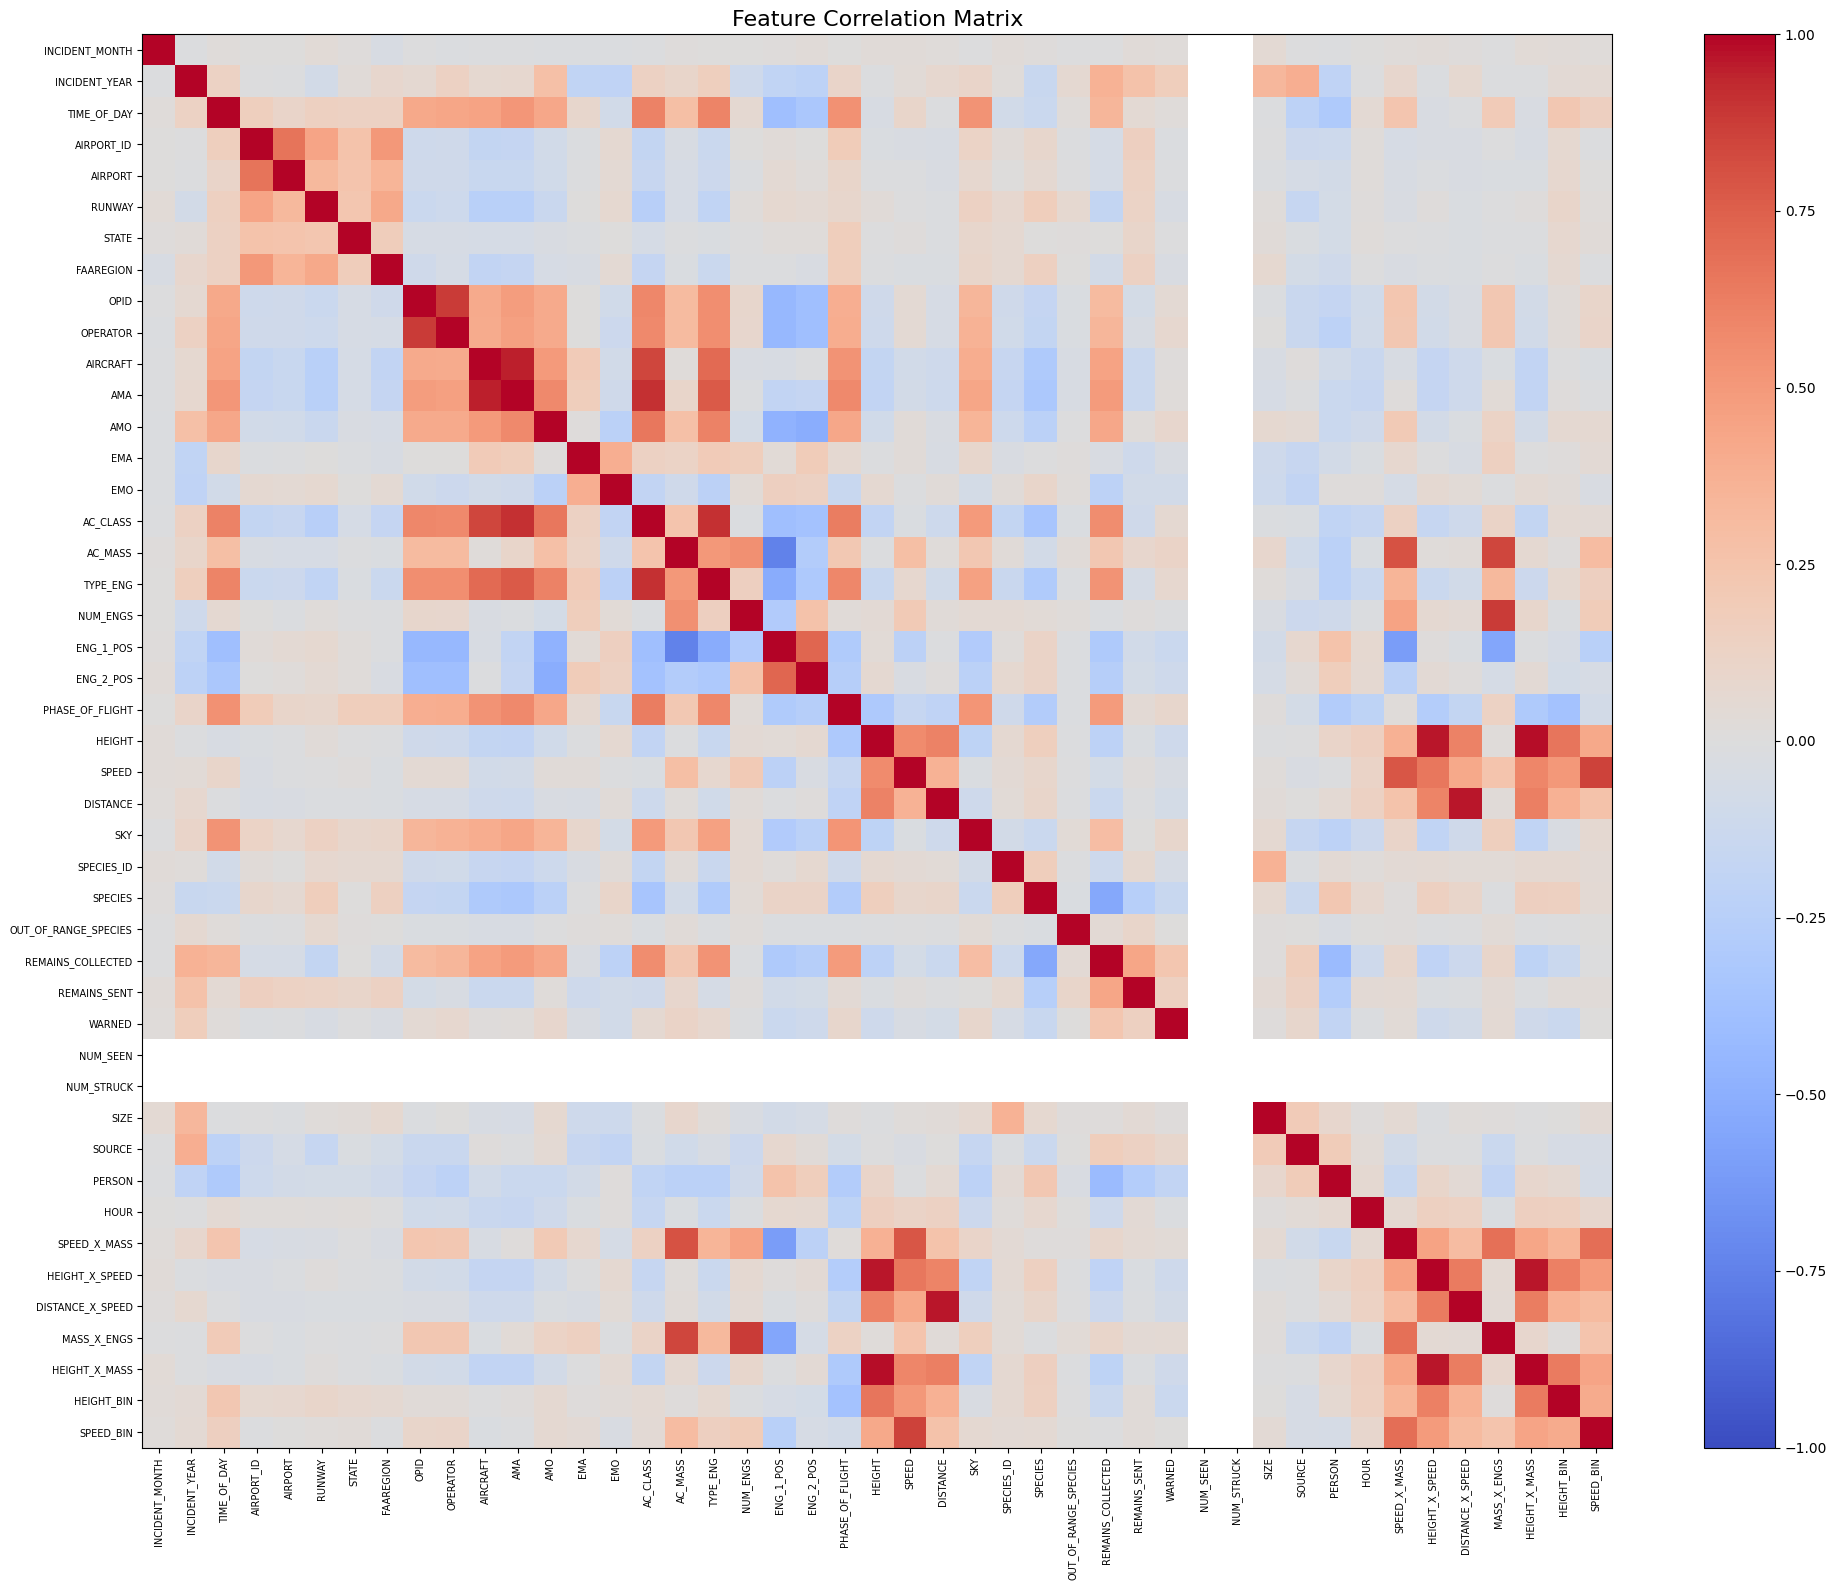

Top 15 features most correlated with INDICATED_DAMAGE:
SIZE                 0.268432
AC_MASS              0.228270
TYPE_ENG             0.205368
ENG_1_POS            0.177108
MASS_X_ENGS          0.160958
AC_CLASS             0.153370
SPECIES_ID           0.139793
SPEED_X_MASS         0.139712
INCIDENT_YEAR        0.138649
OPERATOR             0.134072
PHASE_OF_FLIGHT      0.131628
AMO                  0.130590
OPID                 0.121161
REMAINS_COLLECTED    0.118433
AMA                  0.112025
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [23]:
# Making similarity matrix to see if data is clusterable (We aren't clustering)
# Sample 5000 rows — computing on 307k rows is too slow
X_sample = X_scaled.sample(n=5000, random_state=42)

corr_matrix = X_sample.corr()

fig, ax = plt.subplots(figsize=(20, 16))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

# Add colorbar
plt.colorbar(im, ax=ax)

# Add feature labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr_matrix.columns, fontsize=7)

plt.title("Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

# Top features correlated with target
target_corr = X_scaled.corrwith(y.reset_index(drop=True)).abs().sort_values(ascending=False)
print("Top 15 features most correlated with INDICATED_DAMAGE:")
print(target_corr.head(15))


In [24]:
# Dropping featues that have near-zero variance
zero_var_cols = ["NUM_SEEN", "NUM_STRUCK", "OUT_OF_RANGE_SPECIES"]
for col in zero_var_cols:
    if col in X_scaled.columns:
        X_scaled = X_scaled.drop(columns=[col])

# Drop zero-variance columns from test set
for col in zero_var_cols:
    if col in X_test_scaled.columns:
        X_test_scaled = X_test_scaled.drop(columns=[col])

print("Remaining training features:", X_scaled.shape[1])
print("Remaining test features:", X_test_scaled.shape[1])

Remaining training features: 42
Remaining test features: 42


In [25]:
# Fill any remaining NaNs with 0 (= median after RobustScaler)
X_scaled = X_scaled.fillna(0)
X_test_scaled = X_test_scaled.fillna(0)

print("NaNs remaining in X_scaled:", X_scaled.isnull().sum().sum())
print("NaNs remaining in X_test_scaled:", X_test_scaled.isnull().sum().sum())

# Reset and clean y before model training
y = df["INDICATED_DAMAGE"].reset_index(drop=True)

# Drop any rows where target is NaN
mask = y.notna()
y = y[mask].reset_index(drop=True)
X_scaled = X_scaled[mask].reset_index(drop=True)

print("NaNs in y:", y.isnull().sum())
print("X_scaled shape:", X_scaled.shape)
print("Class counts:\n", y.value_counts())

NaNs remaining in X_scaled: 0
NaNs remaining in X_test_scaled: 0
NaNs in y: 0
X_scaled shape: (307178, 42)
Class counts:
 INDICATED_DAMAGE
0    287651
1     19527
Name: count, dtype: int64


In [ ]:
# Keep all damage records, undersample no-damage to get 60/40 split
damage_idx    = y[y == 1].index
no_damage_idx = y[y == 0].index

n_damage    = len(damage_idx)
n_no_damage = int(n_damage * 1.5)  # 60% no-damage, 40% damage

no_damage_sampled_idx = no_damage_idx.to_series().sample(
    n=n_no_damage, random_state=42
).index

keep_idx = damage_idx.tolist() + no_damage_sampled_idx.tolist()
X_scaled = X_scaled.loc[keep_idx].reset_index(drop=True)
y        = y.loc[keep_idx].reset_index(drop=True)

X_scaled, y = sk_shuffle(X_scaled, y, random_state=42)
X_scaled = X_scaled.reset_index(drop=True)
y        = y.reset_index(drop=True)

print("After undersampling:")
print("  Total rows:    ", len(y))
print("  Damage (1):    ", (y == 1).sum(), f"({(y==1).mean()*100:.1f}%)")
print("  No damage (0): ", (y == 0).sum(), f"({(y==0).mean()*100:.1f}%)")

In [ ]:
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 5 → 3
inner_cv  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ── Reduced hyperparameter grid ───────────────────────────────────
lgbm_params = {
    "n_estimators":      [300, 500],
    "learning_rate":     [0.05, 0.1],
    "max_depth":         [5, 7],
    "num_leaves":        [31, 63],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.8, 1.0],
    "reg_alpha":         [0, 0.1],
    "reg_lambda":        [0, 0.1],
    "min_child_samples": [20, 50]
}

def undersample(X, y, ratio=1.5, seed=42):
    """Undersample majority class to get 60/40 split."""
    damage_idx    = y[y == 1].index
    no_damage_idx = y[y == 0].index
    n_no_damage   = int(len(damage_idx) * ratio)
    
    # Cap at available no-damage samples to avoid ValueError
    n_no_damage = min(n_no_damage, len(no_damage_idx))
    
    sampled_idx = no_damage_idx.to_series().sample(n=n_no_damage, random_state=seed).index
    keep_idx    = damage_idx.tolist() + sampled_idx.tolist()
    X_u = X.loc[keep_idx].reset_index(drop=True)
    y_u = y.loc[keep_idx].reset_index(drop=True)
    return sk_shuffle(X_u, y_u, random_state=seed)

# ── Nested CV — undersample inside each fold ─────────────────────
lgbm_outer_scores = []

for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_scaled, y)):
    print(f"\nOuter Fold {fold+1}/3...")

    X_tr_full = X_scaled.iloc[train_idx].reset_index(drop=True)
    y_tr_full = y.iloc[train_idx].reset_index(drop=True)
    X_val     = X_scaled.iloc[val_idx]
    y_val     = y.iloc[val_idx]

    # Undersample training fold only
    X_tr_under, y_tr_under = undersample(X_tr_full, y_tr_full)

    lgbm_search = RandomizedSearchCV(
        LGBMClassifier(class_weight="balanced", random_state=42,
                       device="gpu", n_jobs=-1, verbose=-1),
        lgbm_params, n_iter=10,
        scoring="balanced_accuracy",
        cv=inner_cv, n_jobs=-1, random_state=42
    )
    lgbm_search.fit(X_tr_under, y_tr_under)
    lgbm_score = balanced_accuracy_score(
        y_val, lgbm_search.best_estimator_.predict(X_val)
    )
    lgbm_outer_scores.append(lgbm_score)
    print(f"  Fold score: {lgbm_score:.4f} | best params: {lgbm_search.best_params_}")

print(f"\n══════════════════════════════════════════")
print(f"  LightGBM Nested CV Balanced Accuracy")
print(f"  {np.mean(lgbm_outer_scores):.4f} +/- {np.std(lgbm_outer_scores):.4f}")
print(f"══════════════════════════════════════════")

# ── Final model on full undersampled dataset ──────────────────────
print("\nFitting final LightGBM on full undersampled dataset...")
X_final, y_final = undersample(X_scaled, y)
print(f"Final training size: {X_final.shape}")
print(f"Class split: {y_final.value_counts().to_dict()}")

lgbm_final = RandomizedSearchCV(
    LGBMClassifier(class_weight="balanced", random_state=42,
                   device="gpu", n_jobs=-1, verbose=-1),
    lgbm_params, n_iter=10,
    scoring="balanced_accuracy",
    cv=inner_cv, n_jobs=-1, random_state=42
)
lgbm_final.fit(X_final, y_final)
best_lgbm = lgbm_final.best_estimator_
print(f"\nBest params: {lgbm_final.best_params_}")

# ── Feature importance — drop bottom 10 features ─────────────────
feat_importance = pd.Series(
    best_lgbm.feature_importances_,
    index=X_final.columns
).sort_values(ascending=False)

print("\nTop 15 features:")
print(feat_importance.head(15))

bottom_features = feat_importance.tail(10).index.tolist()
print("\nDropping bottom 10 features:", bottom_features)

X_scaled      = X_scaled.drop(columns=bottom_features)
X_test_scaled = X_test_scaled.drop(columns=bottom_features)
X_final       = X_final.drop(columns=bottom_features)
print("Shape after dropping:", X_scaled.shape)

# Retrain on cleaned features
print("\nRetraining on cleaned feature set...")
lgbm_final.fit(X_final, y_final)
best_lgbm = lgbm_final.best_estimator_
print("Done.")

scale_pos_weight: 14.73

Outer Fold 1/5...
  Best params: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}
  Fold Balanced Accuracy: 0.8318

Outer Fold 2/5...
  Best params: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}
  Fold Balanced Accuracy: 0.8234

Outer Fold 3/5...
  Best params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
  Fold Balanced Accuracy: 0.8302

Outer Fold 4/5...
  Best params: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}
  Fold Balanced Accuracy: 0.8233

Ou

In [27]:
# ── Threshold tuning on LightGBM ─────────────────────────────────
y_proba_train = best_lgbm.predict_proba(X_final)[:, 1]
y_proba_test  = best_lgbm.predict_proba(X_test_scaled)[:, 1]

best_thresh, best_score = 0.5, 0
for thresh in [i/1000 for i in range(100, 600)]:
    preds = (y_proba_train >= thresh).astype(int)
    score = balanced_accuracy_score(y_final, preds)
    if score > best_score:
        best_score = score
        best_thresh = thresh

print("══════════════════════════════════════════")
print("         TRAIN BALANCED ACCURACY          ")
print("══════════════════════════════════════════")
print(f"  LightGBM:       {best_score:.4f}")
print(f"  Best threshold: {best_thresh:.3f}")
print("══════════════════════════════════════════")

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [17:00:02] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Best threshold: 0.476
Train Balanced Accuracy: 0.8530


In [ ]:
# ── Generate submission ──────────────────────────────────────────
y_pred_final = (y_proba_test >= best_thresh).astype(int)

submission = pd.DataFrame({
    "INDEX_NR": index_nr.values,
    "INDICATED_DAMAGE": y_pred_final
})
submission.to_csv("submission_lgbm.csv", index=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# DECISION STUMP (Decision Tree with max_depth=1)
stump_params = {
    "class_weight": ["balanced"],
    "criterion":    ["gini", "entropy"],
    "splitter":     ["best", "random"]
}
stump_search = RandomizedSearchCV(
    DecisionTreeClassifier(max_depth=1, random_state=42),
    stump_params, n_iter=6, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
stump_search.fit(X_scaled, y)
best_stump = stump_search.best_estimator_

stump_scores = cross_val_score(best_stump, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Decision Stump ──")
print(f"  Best params: {stump_search.best_params_}")
print(f"  CV Balanced Accuracy: {stump_scores.mean():.4f} +/- {stump_scores.std():.4f}")

# BAGGING
bagging_params = {
    "n_estimators":      [50, 100, 200],
    "max_samples":       [0.7, 0.8, 1.0],
    "max_features":      [0.7, 0.8, 1.0],
    "bootstrap":         [True, False]
}
bagging_search = RandomizedSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
        random_state=42
    ),
    bagging_params, n_iter=10, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
bagging_search.fit(X_scaled, y)
best_bagging = bagging_search.best_estimator_

bagging_scores = cross_val_score(best_bagging, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Bagging ──")
print(f"  Best params: {bagging_search.best_params_}")
print(f"  CV Balanced Accuracy: {bagging_scores.mean():.4f} +/- {bagging_scores.std():.4f}")

# RANDOM FOREST
rf_params = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    rf_params, n_iter=15, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
rf_search.fit(X_scaled, y)
best_rf = rf_search.best_estimator_

rf_scores = cross_val_score(best_rf, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Random Forest ──")
print(f"  Best params: {rf_search.best_params_}")
print(f"  CV Balanced Accuracy: {rf_scores.mean():.4f} +/- {rf_scores.std():.4f}")

# BOOSTING (Gradient Boosting)
boost_params = {
    "n_estimators":      [100, 200, 300],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "max_depth":         [3, 4, 5],
    "subsample":         [0.7, 0.8, 1.0],
    "min_samples_leaf":  [1, 2, 4]
}
boost_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    boost_params, n_iter=15, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
boost_search.fit(X_scaled, y)
best_boost = boost_search.best_estimator_

boost_scores = cross_val_score(best_boost, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Boosting ──")
print(f"  Best params: {boost_search.best_params_}")
print(f"  CV Balanced Accuracy: {boost_scores.mean():.4f} +/- {boost_scores.std():.4f}")

# MULTICLASS PARTITIONING (One-vs-Rest)
ovr_params = {
    "estimator__C":        [0.01, 0.1, 1, 10],
    "estimator__solver":   ["lbfgs", "saga"],
    "estimator__max_iter": [200, 500]
}
ovr_search = RandomizedSearchCV(
    OneVsRestClassifier(LogisticRegression(class_weight="balanced", random_state=42)),
    ovr_params, n_iter=10, scoring="balanced_accuracy",
    cv=cv, n_jobs=-1, random_state=42
)
ovr_search.fit(X_scaled, y)
best_ovr = ovr_search.best_estimator_

ovr_scores = cross_val_score(best_ovr, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Multiclass Partitioning (OvR) ──")
print(f"  Best params: {ovr_search.best_params_}")
print(f"  CV Balanced Accuracy: {ovr_scores.mean():.4f} +/- {ovr_scores.std():.4f}")

# STACKING
stacking = StackingClassifier(
    estimators=[
        ("stump",   best_stump),
        ("bagging", best_bagging),
        ("rf",      best_rf),
        ("boost",   best_boost),
        ("ovr",     best_ovr)
    ],
    final_estimator=LogisticRegression(class_weight="balanced", random_state=42),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_scaled, y)

stacking_scores = cross_val_score(stacking, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Stacking ──")
print(f"  CV Balanced Accuracy: {stacking_scores.mean():.4f} +/- {stacking_scores.std():.4f}")


# VOTING ENSEMBLE (best models combined)
voting = VotingClassifier(
    estimators=[
        ("stump",    best_stump),
        ("bagging",  best_bagging),
        ("rf",       best_rf),
        ("boost",    best_boost),
        ("ovr",      best_ovr),
        ("stacking", stacking)
    ],
    voting="soft",
    n_jobs=-1
)
voting.fit(X_scaled, y)

voting_scores = cross_val_score(voting, X_scaled, y, cv=cv, scoring="balanced_accuracy")
print("── Voting Ensemble ──")
print(f"  CV Balanced Accuracy: {voting_scores.mean():.4f} +/- {voting_scores.std():.4f}/")

results = {
    "Decision Stump":          stump_scores.mean(),
    "Bagging":                 bagging_scores.mean(),
    "Random Forest":           rf_scores.mean(),
    "Boosting":                boost_scores.mean(),
    "Multiclass Part. (OvR)": ovr_scores.mean(),
    "Stacking":                stacking_scores.mean(),
    "Voting Ensemble":         voting_scores.mean()
}
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<28} {score:.4f}")

print(f"Best model: {max(results, key=results.get)}")
print(f"Best Balanced Accuracy: {max(results.values()):.4f}")

#  Generate predictions using best voting ensemble
y_pred = voting.predict(X_test_scaled)

# Build submission file
submission = pd.DataFrame({
    "INDEX_NR": index_nr.values,
    "INDICATED_DAMAGE": y_pred
})

submission.to_csv("submission.csv", index=False)
print(submission["INDICATED_DAMAGE"].value_counts())
print(submission["INDICATED_DAMAGE"].value_counts(normalize=True).mul(100).round(2))

## Improved pipeline (v2)

Fixes: OOF threshold tuning, no undersampling (uses `scale_pos_weight`), native categorical handling, OOF target encoding, date features, missing-indicator features, LightGBM + XGBoost + CatBoost ensemble, early stopping. Writes `submission_improved.csv`.


In [ ]:
# ═══ IMPROVED PIPELINE v3 — Setup ═══
# Run once (Colab / fresh env):
# !pip install -q catboost lightgbm xgboost

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

SEED = 42
N_SPLITS = 10                   # 5 → 10 for a tighter OOF estimate
TARGET = "INDICATED_DAMAGE"
ID_COL = "INDEX_NR"

# Flip to True on a GPU runtime (Colab: Runtime → Change runtime type → GPU).
# On CPU, LightGBM/XGBoost will error with GPU flags, so keep False locally.
USE_GPU = True

# Seed bagging — 3 seeds smooths out fold-to-fold variance (~3x runtime).
SEEDS = (42, 7, 13)


In [ ]:
# ═══ Load raw data ═══
train_raw = pd.read_csv("train.csv", na_values=["?"], low_memory=False)
test_raw  = pd.read_csv("test.csv",  na_values=["?"], low_memory=False)

# Normalize target to 0/1 regardless of whether it's Y/N or already numeric
y_raw = train_raw[TARGET].dropna()
if set(y_raw.astype(str).str.upper().unique()) <= {"Y", "N"}:
    y = (train_raw[TARGET].astype(str).str.upper() == "Y").astype(int).values
else:
    y = train_raw[TARGET].astype(int).values
print("Class balance:", pd.Series(y).value_counts(normalize=True).round(3).to_dict())


In [ ]:
# ═══ Preprocessing ═══
DROP_COLS = [
    "BIRD_BAND_NUMBER", "ENG_4_POS", "ENROUTE_STATE", "PRECIPITATION",
    "ENG_3_POS", "LOCATION", "COMMENTS", "REMARKS",
    "FLT", "REG", "LUPDATE", "TRANSFER",
]  # NOTE: INCIDENT_DATE, LAT, LON, NUM_SEEN kept

# AMA/AMO/EMA/EMO are integer codes (Aircraft Make/Model, Engine Make/Model)
# — they're categorical, NOT continuous. Convert to string before any
# numeric imputation so they end up in cat_cols and get target-encoded.
CODE_AS_CAT = ["AMA", "AMO", "EMA", "EMO"]

def preprocess(train, test):
    train, test = train.copy(), test.copy()

    # Coerce integer-coded categoricals to strings BEFORE any numeric handling
    for df in (train, test):
        for c in CODE_AS_CAT:
            if c in df.columns:
                df[c] = df[c].astype("Int64").astype(str).replace({"<NA>": np.nan})

    # Missing-indicator flags BEFORE imputation
    miss_cols = ["SPEED", "HEIGHT", "DISTANCE", "AC_MASS", "NUM_ENGS",
                 "SKY", "SPECIES", "AIRPORT", "TIME", "LATITUDE", "LONGITUDE"]
    for c in miss_cols:
        if c in train.columns:
            train[f"{c}_MISS"] = train[c].isna().astype(int)
            test[f"{c}_MISS"]  = test[c].isna().astype(int)

    # Date features from INCIDENT_DATE
    for df in (train, test):
        if "INCIDENT_DATE" in df.columns:
            dt = pd.to_datetime(df["INCIDENT_DATE"], errors="coerce")
            df["YEAR"]         = dt.dt.year.astype("Int64")
            df["MONTH"]        = dt.dt.month.astype("Int64")
            df["DAYOFYEAR"]    = dt.dt.dayofyear.astype("Int64")
            df["DAYOFWEEK"]    = dt.dt.dayofweek.astype("Int64")
            df["IS_MIGRATION"] = dt.dt.month.isin([3, 4, 5, 9, 10, 11]).astype(int)
            df["SEASON"]       = ((dt.dt.month % 12) // 3).astype("Int64")
            # Cyclical encoding so trees can use seasonality smoothly
            mo = dt.dt.month.fillna(0).astype(float)
            df["MONTH_SIN"] = np.sin(2 * np.pi * mo / 12.0)
            df["MONTH_COS"] = np.cos(2 * np.pi * mo / 12.0)

    # Drop ID-ish / high-NaN / date
    for df in (train, test):
        for c in DROP_COLS + ["INCIDENT_DATE"]:
            if c in df.columns:
                df.drop(columns=[c], inplace=True)

    # TIME → HOUR (+ cyclical encoding)
    for df in (train, test):
        if "TIME" in df.columns:
            df["HOUR"] = pd.to_numeric(
                df["TIME"].astype(str).str.split(":").str[0], errors="coerce"
            )
            hr = df["HOUR"].fillna(-1).astype(float)
            df["HOUR_SIN"] = np.where(hr >= 0, np.sin(2 * np.pi * hr / 24.0), 0.0)
            df["HOUR_COS"] = np.where(hr >= 0, np.cos(2 * np.pi * hr / 24.0), 0.0)
            df.drop(columns=["TIME"], inplace=True)

    # Hand-crafted features
    # NOTE: NUM_STRUCK is constant (=1) on every non-null row in this dataset,
    # so log/MULTI_STRIKE features carry zero signal — dropped.
    for df in (train, test):
        df["NUM_SEEN"] = pd.to_numeric(df.get("NUM_SEEN"), errors="coerce")
        # Phase-of-flight risk flags. EDA: En Route ~29% damage, Climb ~14.5%,
        # Descent ~14.7% — all higher than landing/takeoff in some slices.
        df["IS_LANDING"]  = (df.get("PHASE_OF_FLIGHT") == "Landing Roll").astype(int)
        df["IS_TAKEOFF"]  = (df.get("PHASE_OF_FLIGHT") == "Take-off Run").astype(int)
        df["IS_APPROACH"] = (df.get("PHASE_OF_FLIGHT") == "Approach").astype(int)
        df["IS_ENROUTE"]  = (df.get("PHASE_OF_FLIGHT") == "En Route").astype(int)
        df["IS_CLIMB"]    = (df.get("PHASE_OF_FLIGHT") == "Climb").astype(int)
        df["IS_DESCENT"]  = (df.get("PHASE_OF_FLIGHT") == "Descent").astype(int)
        df["IS_NIGHT"]    = (df.get("TIME_OF_DAY") == "Night").astype(int)
        # Ordinal SIZE — captures the Small<Medium<Large damage gradient
        # (EDA: Small=2.0%, Medium=12.6%, Large=32.6%).
        size_map = {"Small": 0, "Medium": 1, "Large": 2}
        df["SIZE_ORD"] = df.get("SIZE").map(size_map).fillna(0.5)
        df["IS_LARGE_BIRD"] = (df.get("SIZE") == "Large").astype(int)
        # Numeric interactions
        df["SPEED_X_MASS"]   = df.get("SPEED") * df.get("AC_MASS")
        df["HEIGHT_X_SPEED"] = df.get("HEIGHT") * df.get("SPEED")
        df["MASS_X_ENGS"]    = df.get("AC_MASS") * df.get("NUM_ENGS")

    # Numeric imputation — train medians only (no leakage)
    num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in (TARGET, ID_COL)]
    medians = train[num_cols].median()
    train[num_cols] = train[num_cols].fillna(medians)
    test[num_cols]  = test[num_cols].fillna(medians)

    # Fill categoricals with "Unknown"
    cat_cols_raw = [c for c in train.select_dtypes(include=["object"]).columns if c != TARGET]
    for df in (train, test):
        for c in cat_cols_raw:
            df[c] = df[c].fillna("Unknown").astype(str)

    # Cross-column combined keys (captured by TE later).
    # More keys + interactions where damage rates differ sharply.
    for df in (train, test):
        if "SPECIES" in df.columns and "PHASE_OF_FLIGHT" in df.columns:
            df["SPECIES_X_PHASE"]    = df["SPECIES"] + "__" + df["PHASE_OF_FLIGHT"]
        if "SPECIES" in df.columns and "SIZE" in df.columns:
            df["SPECIES_X_SIZE"]     = df["SPECIES"] + "__" + df["SIZE"]
        if "AIRPORT" in df.columns and "TIME_OF_DAY" in df.columns:
            df["AIRPORT_X_TIME"]     = df["AIRPORT"] + "__" + df["TIME_OF_DAY"]
        if "OPERATOR" in df.columns and "AC_CLASS" in df.columns:
            df["OPERATOR_X_ACCLASS"] = df["OPERATOR"] + "__" + df["AC_CLASS"]
        if "SPECIES" in df.columns and "STATE" in df.columns:
            df["SPECIES_X_STATE"]    = df["SPECIES"] + "__" + df["STATE"]
        if "AIRCRAFT" in df.columns and "PHASE_OF_FLIGHT" in df.columns:
            df["AIRCRAFT_X_PHASE"]   = df["AIRCRAFT"] + "__" + df["PHASE_OF_FLIGHT"]

    # Re-select cat_cols to include combined keys
    cat_cols = [c for c in train.select_dtypes(include=["object"]).columns if c != TARGET]

    return train, test, cat_cols

train_proc, test_proc, cat_cols = preprocess(train_raw, test_raw)
test_ids = test_proc[ID_COL].values
X      = train_proc.drop(columns=[TARGET, ID_COL])
X_test = test_proc.drop(columns=[ID_COL])
print("X:", X.shape, "| X_test:", X_test.shape, "| cats:", len(cat_cols))


In [ ]:
# ═══ Groupby aggregation features (no target leakage — uses X only) ═══
# NUM_STRUCK_LOG removed: NUM_STRUCK is constant (=1) on every non-null row,
# so any aggregation of it is also constant.
AGG_KEYS = [c for c in ["SPECIES", "AIRPORT", "OPERATOR", "AIRCRAFT", "STATE"] if c in X.columns]
AGG_VALS = [c for c in ["SPEED", "HEIGHT", "AC_MASS", "HOUR"] if c in X.columns]

def add_groupby_aggs(X_tr, X_te, keys, vals):
    X_tr, X_te = X_tr.copy(), X_te.copy()
    for k in keys:
        # frequency (strike count per category)
        freq = X_tr[k].value_counts()
        X_tr[f"FREQ_{k}"] = X_tr[k].map(freq).astype(float)
        X_te[f"FREQ_{k}"] = X_te[k].map(freq).fillna(0).astype(float)
        # mean of each numeric col, grouped by k
        for v in vals:
            stats = X_tr.groupby(k)[v].mean()
            X_tr[f"{v}_mean_BY_{k}"] = X_tr[k].map(stats).astype(float)
            X_te[f"{v}_mean_BY_{k}"] = X_te[k].map(stats).astype(float)
    # Fill any leftover NaN (unseen categories in test) with global mean
    for col in X_tr.columns:
        if col.startswith("FREQ_") or "_mean_BY_" in col:
            g = X_tr[col].mean()
            X_tr[col] = X_tr[col].fillna(g)
            X_te[col] = X_te[col].fillna(g)
    return X_tr, X_te

X, X_test = add_groupby_aggs(X, X_test, AGG_KEYS, AGG_VALS)
print(f"After aggregation features: X={X.shape}")


In [ ]:
# ═══ Out-of-fold target encoding (high-cardinality + combined keys) ═══
# AMA/AMO/EMA/EMO added — they're integer codes (Aircraft Make/Model,
# Engine Make/Model) with very different damage rates per code, so TE
# is exactly the right encoding. Cross keys also expanded.
HIGH_CARD = [c for c in [
    "SPECIES", "AIRPORT", "AIRPORT_ID", "OPERATOR", "OPID", "AIRCRAFT",
    "AMA", "AMO", "EMA", "EMO",
    "SPECIES_X_PHASE", "SPECIES_X_SIZE", "AIRPORT_X_TIME", "OPERATOR_X_ACCLASS",
    "SPECIES_X_STATE", "AIRCRAFT_X_PHASE",
] if c in X.columns]

def oof_target_encode(X_tr, y_tr, X_te, cols, n_splits=N_SPLITS, smooth=20, seed=SEED):
    X_tr, X_te = X_tr.copy(), X_te.copy()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    prior = y_tr.mean()
    for col in cols:
        oof = np.zeros(len(X_tr))
        for tr, va in skf.split(X_tr, y_tr):
            agg = (pd.DataFrame({col: X_tr.iloc[tr][col].values, "y": y_tr[tr]})
                   .groupby(col)["y"].agg(["mean", "count"]))
            s = (agg["mean"] * agg["count"] + prior * smooth) / (agg["count"] + smooth)
            oof[va] = X_tr.iloc[va][col].map(s).fillna(prior).values
        agg = (pd.DataFrame({col: X_tr[col].values, "y": y_tr})
               .groupby(col)["y"].agg(["mean", "count"]))
        s = (agg["mean"] * agg["count"] + prior * smooth) / (agg["count"] + smooth)
        X_tr[f"{col}_TE"] = oof
        X_te[f"{col}_TE"] = X_te[col].map(s).fillna(prior).values
    return X_tr, X_te

X, X_test = oof_target_encode(X, y, X_test, HIGH_CARD)
print(f"After TE: X={X.shape}  ({len(HIGH_CARD)} TE cols added)")


In [ ]:
# ═══ Per-model feature prep ═══
# LightGBM: category dtype (native split)
X_lgb, X_test_lgb = X.copy(), X_test.copy()
for c in cat_cols:
    if c in X_lgb.columns:
        X_lgb[c] = X_lgb[c].astype("category")
        cats = X_lgb[c].cat.categories
        X_test_lgb[c] = pd.Categorical(X_test_lgb[c], categories=cats)

# XGBoost: integer-encode cats (aligned), stay numeric
X_xgb, X_test_xgb = X.copy(), X_test.copy()
for c in cat_cols:
    if c in X_xgb.columns:
        cats = X_xgb[c].astype("category").cat.categories
        X_xgb[c]      = pd.Categorical(X_xgb[c], categories=cats).codes
        X_test_xgb[c] = pd.Categorical(X_test_xgb[c], categories=cats).codes

# CatBoost: raw strings, cat indices
X_cb, X_test_cb = X.copy(), X_test.copy()
cat_idx = [X_cb.columns.get_loc(c) for c in cat_cols if c in X_cb.columns]

neg, pos = (y == 0).sum(), (y == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.2f}")


In [ ]:
# ═══ Generic OOF trainer (with optional seed bagging) ═══
def get_oof(model_factory, X_tr, y_tr, X_te, n_splits=N_SPLITS,
            fit_kwargs=None, seeds=SEEDS, name=""):
    fit_kwargs = fit_kwargs or {}
    oof = np.zeros(len(X_tr))
    preds = np.zeros(len(X_te))
    oof_counts = np.zeros(len(X_tr))
    pred_count = 0
    for s in seeds:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=s)
        for fold, (tr, va) in enumerate(skf.split(X_tr, y_tr)):
            X_a, X_b = X_tr.iloc[tr], X_tr.iloc[va]
            y_a, y_b = y_tr[tr], y_tr[va]
            m = model_factory()
            fk = dict(fit_kwargs)
            fk.setdefault("eval_set", [(X_b, y_b)])
            m.fit(X_a, y_a, **fk)
            p_val = m.predict_proba(X_b)[:, 1]
            p_te  = m.predict_proba(X_te)[:, 1]
            oof[va] += p_val
            oof_counts[va] += 1
            preds += p_te
            pred_count += 1
            ba = balanced_accuracy_score(y_b, (p_val > 0.5).astype(int))
            print(f"  [{name}] seed={s} fold={fold+1}/{n_splits} BA={ba:.4f}")
    oof   = oof / np.maximum(oof_counts, 1)
    preds = preds / pred_count
    return oof, preds


In [ ]:
# ═══ LightGBM ═══
# scale_pos_weight=1 (i.e. NO class weighting): with OOF threshold tuning
# below, double-correcting hurts balanced accuracy. Let probabilities stay
# calibrated and let the threshold do the rebalancing.
def lgb_factory():
    params = dict(
        n_estimators=3000, learning_rate=0.03,
        num_leaves=63, max_depth=-1,
        min_child_samples=40, reg_alpha=0.1, reg_lambda=0.1,
        subsample=0.8, subsample_freq=5, colsample_bytree=0.8,
        scale_pos_weight=1.0, random_state=SEED, n_jobs=-1, verbose=-1,
    )
    if USE_GPU:
        params.update(device="gpu", gpu_platform_id=0, gpu_device_id=0)
    return LGBMClassifier(**params)

print("=== LightGBM ===")
oof_lgb, pred_lgb = get_oof(
    lgb_factory, X_lgb, y, X_test_lgb,
    fit_kwargs={
        "callbacks": [early_stopping(100, verbose=False), log_evaluation(0)],
        "categorical_feature": [c for c in cat_cols if c in X_lgb.columns],
    },
    name="LGB",
)
print(f"LGB OOF BA @0.5 = {balanced_accuracy_score(y, (oof_lgb>0.5).astype(int)):.4f}")


In [ ]:
# ═══ XGBoost ═══
# scale_pos_weight=1 — same reasoning as LightGBM (threshold tuning
# handles the imbalance, double-correcting hurts).
def xgb_factory():
    params = dict(
        n_estimators=3000, learning_rate=0.03,
        max_depth=7, min_child_weight=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=1.0, random_state=SEED, n_jobs=-1,
        tree_method="hist", eval_metric="logloss",
        early_stopping_rounds=100, verbosity=0,
    )
    if USE_GPU:
        # XGBoost 2.x API: use device="cuda" with tree_method="hist"
        params["device"] = "cuda"
    return XGBClassifier(**params)

print("=== XGBoost ===")
oof_xgb, pred_xgb = get_oof(xgb_factory, X_xgb, y, X_test_xgb, name="XGB")
print(f"XGB OOF BA @0.5 = {balanced_accuracy_score(y, (oof_xgb>0.5).astype(int)):.4f}")


In [ ]:
# ═══ CatBoost ═══
# auto_class_weights removed — same reasoning as LGB/XGB: threshold
# tuning on OOF probabilities handles the imbalance more cleanly than
# weighting the loss.
def cb_factory():
    params = dict(
        iterations=3000, learning_rate=0.05,
        depth=7, l2_leaf_reg=5,
        cat_features=cat_idx,
        random_seed=SEED, verbose=0,
        early_stopping_rounds=100,
    )
    if USE_GPU:
        params["task_type"] = "GPU"
        params["devices"]   = "0"
    return CatBoostClassifier(**params)

print("=== CatBoost ===")
oof_cb, pred_cb = get_oof(cb_factory, X_cb, y, X_test_cb, name="CB")
print(f"CB OOF BA @0.5 = {balanced_accuracy_score(y, (oof_cb>0.5).astype(int)):.4f}")


In [ ]:
# ═══ Stacking meta-learner + threshold tuning ═══
# Compare three strategies on OOF: individual models, mean ensemble, stacked LR
mean_oof  = (oof_lgb  + oof_xgb  + oof_cb)  / 3.0
mean_pred = (pred_lgb + pred_xgb + pred_cb) / 3.0

# Stacked: LogisticRegression meta-learner on OOF probs, fitted via its own k-fold
meta_X = np.column_stack([oof_lgb, oof_xgb, oof_cb])
meta_X_te = np.column_stack([pred_lgb, pred_xgb, pred_cb])

meta_oof = np.zeros(len(y))
meta_pred = np.zeros(len(meta_X_te))
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
for tr, va in skf.split(meta_X, y):
    meta = LogisticRegression(C=1.0, class_weight="balanced",
                              max_iter=2000, random_state=SEED)
    meta.fit(meta_X[tr], y[tr])
    meta_oof[va] = meta.predict_proba(meta_X[va])[:, 1]
    meta_pred   += meta.predict_proba(meta_X_te)[:, 1] / N_SPLITS

def tune(oof_probs):
    bt, bs = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.002):
        s = balanced_accuracy_score(y, (oof_probs >= t).astype(int))
        if s > bs:
            bs, bt = s, t
    return bt, bs

print("─── OOF Balanced Accuracy (tuned threshold) ───")
results = {}
for name, o, p in [
    ("LGB alone", oof_lgb, pred_lgb),
    ("XGB alone", oof_xgb, pred_xgb),
    ("CB alone",  oof_cb,  pred_cb),
    ("Mean ens",  mean_oof,  mean_pred),
    ("Stacked",   meta_oof,  meta_pred),
]:
    t, s = tune(o)
    results[name] = (s, t, o, p)
    print(f"  {name:10s}: BA={s:.4f} @ t={t:.3f}")

# Pick the winner (highest OOF BA)
winner_name = max(results, key=lambda k: results[k][0])
final_score, final_thresh, _, final_pred = results[winner_name]
print(f"\n→ Winner: {winner_name}  (OOF BA={final_score:.4f}, t={final_thresh:.3f})")


In [ ]:
# ═══ Write submission_improved.csv ═══
y_pred_final = (final_pred >= final_thresh).astype(int)
submission = pd.DataFrame({ID_COL: test_ids, TARGET: y_pred_final})
submission.to_csv("submission_improved.csv", index=False)
print(submission[TARGET].value_counts())
print(f"Wrote submission_improved.csv using: strategy={winner_name}, "
      f"threshold={final_thresh:.3f}, OOF BA={final_score:.4f}")
